In [28]:
import sys
sys.path.append('../')
import  os
num_cores = "1"
os.environ["OPENBLAS_NUM_THREADS"] = num_cores
os.environ["OMP_NUM_THREADS"] = num_cores
os.environ["MKL_NUM_THREADS"] = num_cores

from scipy.ndimage import gaussian_filter

import qutip as qt
import utils_2Q_gate_zp as ut
import numpy as np
import matplotlib.pyplot as plt
workers=150

def plot_evolution(hspace, tlist, props, logical = [0,2], intermediate=9, divide=10, s = 0.1, suptitle=""):

    # Get population of logical states, intermediate states, and other states < or >= divide
    pops = np.zeros((2, 5, len(props)))
    logical_idx = [hspace.index(i) for i in logical]
    int_idx = hspace.index(intermediate)
    others_low = [i for i in range(props[0].shape[0]) if i not in logical_idx and i != int_idx and i < divide]
    others_high = [i for i in range(props[0].shape[0]) if i not in logical_idx and i != int_idx and i > divide]
    f, ax = plt.subplots(ncols=2, figsize=(8,3))
    for i in range(len(logical_idx)):
        pops[i,0] = np.abs([p[logical_idx[i], logical_idx[0]] for p in props])**2
        pops[i,1] = np.abs([p[logical_idx[i], logical_idx[1]] for p in props])**2
        pops[i,2] = np.abs([p[logical_idx[i], int_idx] for p in props])**2
        for o in others_low:
            pops[i,3] += np.abs([p[logical_idx[i], o] for p in props])**2
        for o in others_high:
            pops[i,4] += np.abs([p[logical_idx[i], o] for p in props])**2

        ax[i].plot(tlist, gaussian_filter(pops[i, 0], s), label=logical[0])
        ax[i].plot(tlist, gaussian_filter(pops[i, 1], s),label=logical[1])
        ax[i].plot(tlist, gaussian_filter(pops[i, 2], s), label=intermediate)
        ax[i].plot(tlist, gaussian_filter(pops[i, 3], s), label=f"others < {divide}")
        ax[i].plot(tlist, gaussian_filter(pops[i, 4], s), label=f"others >= {divide}")
        ax[i].legend()
        ax[i].set_title("Start in " + str(hspace[i]))
        ax[i].set_xlabel("time (ns)")
        ax[i].set_ylabel("population")
    if suptitle != "":
        plt.suptitle(suptitle)
    return pops

The point of this notebook is to provide an example of a control pulse on a single qubit X gate which performs well with few states, but performs poorly when more are included. To do this we consider driving the $n_\phi$ operator for a single qubit X gate in zero pi.

Using the reduced model notebook, we previously showed that most of the leakage is coming through the states: [10, 11, 16, 19, 23, 25, 31, 33]  

First define the system Hamiltonian

In [2]:
trunc1 = 300
[H0, drive_term, w_trans_1, w_trans_2, hspace_charge] = ut.zero_pi_initialize(drive_phi=True, drive_theta=False, truncation=trunc1, thresh=0)
H0 = H0 - H0[0,0]

In [3]:
H0

Quantum object: dims = [[300], [300]], shape = (300, 300), type = oper, isherm = True
Qobj data =
[[  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.          15.75356226   0.         ...   0.           0.
    0.        ]
 [  0.           0.          21.37876083 ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ... 349.98468405   0.
    0.        ]
 [  0.           0.           0.         ...   0.         350.04817049
    0.        ]
 [  0.           0.           0.         ...   0.           0.
  350.94033957]]

Drive params

In [ ]:
# tg_wiggle, amp_A, amp_B, detune_A, detune_B, alpha_A = [-1.61880996, 0.5638094, 0.66464448, -0.22691617, -0.47345273, 0]
tg_wiggle, amp_A, amp_B, detune_A, detune_B, alpha_A = [-2.02513517, 0.21160303,  0.10911951, -0.03935263 , 0.02558899 , 0.        ]
tg = 100+tg_wiggle

tg_wiggle, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.9029999310786319, 0.022073592159162141, 0.0231926859121433, -0.006843538348239284, -0.004178164800861717, 0.0]
tg = 200+tg_wiggle

tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.7931350386642599, 0.01376931681864476, 0.015968337320101306, 0.003859050119665002, 0.005118450809580633, 0.0]
# tg_mod, amp_A, amp_B, detune_A, detune_B, alpha_A = [0.7931350386642599, 0.01376931681864476, 0.015968337320101306, 0.003859050119665002, 0.005118450809580633, 0.0]
tg_base = 1000
tg = tg_base+tg_mod

pulse_args = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': 0 }
pulse_args

{'drive_amp_A': 0.01376931681864476,
 'drive_freq_A': 50.91874110010799,
 'drive_amp_B': 0.015968337320101306,
 'drive_freq_B': 29.547893313812356,
 'gate_time': 1000.7931350386642,
 'alpha_A': 0.0,
 'alpha_B': 0}

# Show fidelities and plot populations

In [5]:
# hspace_reduced = [0, 2, 9, 10, 11, 16, 19, 23, 25, 31, 33]
hspace_reduced = [0, 2, 9, 10, 11, 16, 18, 19, 31, 33, 37, 46, 53, 55, 69, 76, 92, 100, 126]
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_reduced, workers, tg,
                amp_A, amp_B, detune_A, detune_B, 0, 0]

In [33]:
# Save to npz for julia
np.savez("H_phi.npz", H0=H0, drive=drive_term, w_trans_1=w_trans_1, w_trans_2=w_trans_2, hspace_reduced=hspace_reduced, hspace_full=np.arange(trunc1))

In [6]:
ut.xgate_fidelity(argz)

-2.0982488995701805

In [ ]:
args = [H0, drive_term, w_trans_1, w_trans_2, hspace_reduced, tg_base, 1]
arg = [tg_mod, amp_A, amp_B, detune_A, detune_B]
ut.xgate_fidelity_optimize_tg_wiggle(arg, *args)

In [7]:
tlist, props = ut.xgate_propagator(argz, num=300)

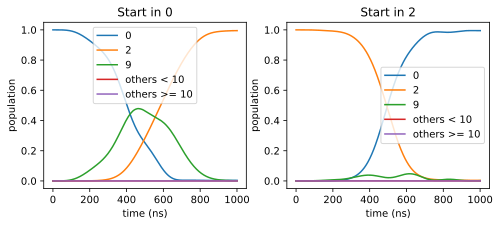

In [ ]:
plot_evolution(hspace_reduced, tlist, props, s = 1, suptitle="16 State Model");

In [14]:
hspace_full = list(np.arange(300))
argz = [H0, drive_term, w_trans_1, w_trans_2, hspace_full, workers, tg,
                amp_A, amp_B, detune_A, detune_B, alpha_A, 0]

In [10]:
ut.xgate_fidelity(argz)

-1.9726881200376347

In [15]:
tlist, props = ut.xgate_propagator(argz, num=300)

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_yscale'

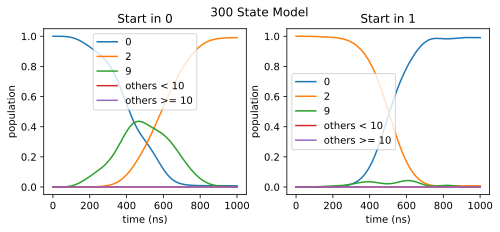

In [31]:
plot_evolution(hspace_full, tlist, props, suptitle="300 State Model");
plt.set_yscale("log")

# Old -- Rotating Frame

Look at dynamics in a roatating frame:

$$
U = |0\rangle\langle 0|e^{-i(E_9-\omega_A)t} + |2\rangle\langle 2|e^{-i(E_9-\omega_B)t} + |9\rangle\langle 9|e^{-iE_9t}
$$
and for other $n$:
$$
|n\rangle\langle n|e^{-iE_9t}
$$



In [ ]:
def U(t, E_int, pulse_args, hspace, logical_idx = [0,1], intermediate=9):
    u = np.zeros((len(hspace), len(hspace)), dtype=np.complex128)
    for i in range(len(hspace)):
        if i == logical_idx[0]:
            u[i,i] = np.exp(-1.0j*(E_int - pulse_args["drive_freq_A"])*t)
        elif i == logical_idx[1]:
            u[i,i] = np.exp(-1.0j*(E_int - pulse_args["drive_freq_B"])*t)
        else:
            u[i,i] = np.exp(1.0j*E_int*t)
    
    return u

plot_evolution(argz, U = lambda t: U(t, w_trans_1, pulse_args, hspace_reduced));

# Other

In [ ]:
# 500 ns phi gate
# Differential_evolution step 908: f(x)= -3.79937
# Best Soln: [-1.58325328, 0.20769485, 0.5965205, 0.32459243, 0.33639606, 0]
# convergence 0.0564